### Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import mlflow
import logging
from matplotlib import patches
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch import optim
from src.org_unet_parts import *
from dataloader import ACDCDataset
from utils.utils import EarlyStopping
from utils.roi_predictor_evaluation_metrics import evaluate_iou, evaluate_regression_metrics
%matplotlib inline

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.21 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [2]:
exp_run_id = f'acdc_roi_predictor_img_slices_with_ratios_v4{datetime.now().strftime("%Y%m%d%H%M%S")}'
log_file_name = f'./logs/{exp_run_id}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [4]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-roi-predictor")

2024/11/20 23:10:55 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/624151531129907', creation_time=1732043488953, experiment_id='624151531129907', last_update_time=1732121664745, lifecycle_stage='active', name='/cmri-roi-predictor', tags={'mlflow.experiment.sourceName': '/cmri-roi-predictor',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [5]:
dir_checkpoint = Path('./models/checkpoints/cnn_v1_img_slices_with_ratios_v4/')

epochs = 100
batch_size = 16
lr = 5e-4
scale = 1
amp = False

### Data Loading

In [6]:
root_dir = r'../data/ACDC/img_slices_with_ratios_v4/'
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training', crop_resize_ind=True, margin=0.05)
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation', crop_resize_ind=True, margin=0.05)
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing', crop_resize_ind=True, margin=0.05)

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 16000 training images
Loaded 2000 validation images
Loaded 2000 testing images


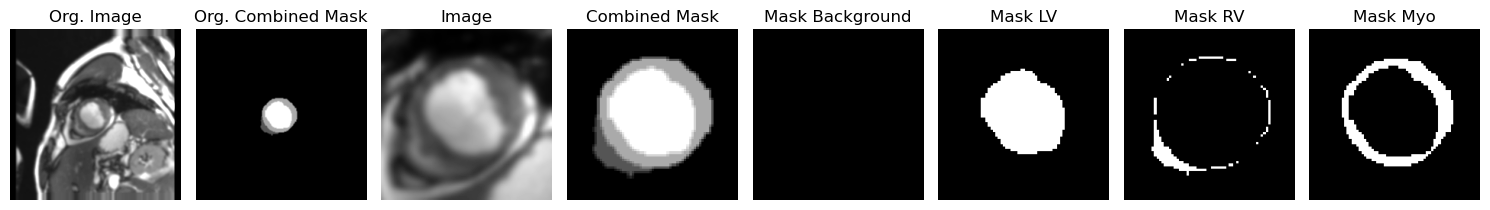

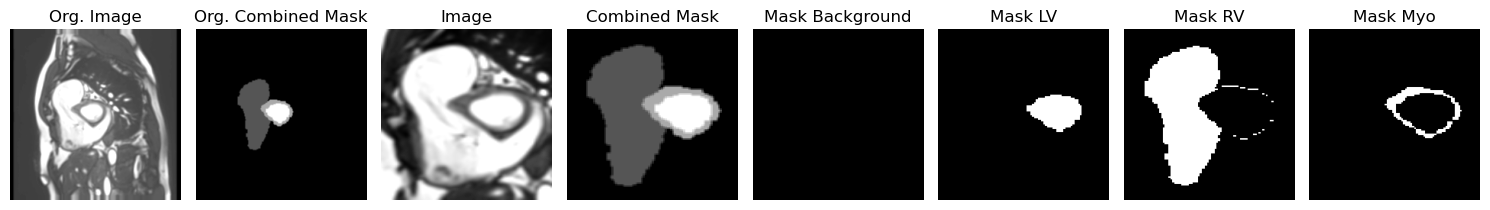

In [7]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break

    # Extract data from the sample
    org_image = sample['org_image'][i].squeeze().numpy()
    image = sample['image'][i].squeeze().numpy()
    org_msk_all = sample['org_masks_all'][i].squeeze().numpy()
    msk_all = sample['masks_all'][i].squeeze().numpy()
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 8, figsize=(15, 5))

    # Plot the image and masks
    axes[0].imshow(org_image, cmap='gray')
    axes[0].set_title('Org. Image')
    axes[0].axis('off')
    
    axes[1].imshow(org_msk_all, cmap='gray')
    axes[1].set_title('Org. Combined Mask')
    axes[1].axis('off')
    
    axes[2].imshow(image, cmap='gray')
    axes[2].set_title('Image')
    axes[2].axis('off')
    
    axes[3].imshow(msk_all, cmap='gray')
    axes[3].set_title('Combined Mask')
    axes[3].axis('off')
    
    axes[4].imshow(msk_bkg, cmap='gray')
    axes[4].set_title('Mask Background')
    axes[4].axis('off')
    
    axes[5].imshow(msk_lv, cmap='gray')
    axes[5].set_title('Mask LV')
    axes[5].axis('off')
    
    axes[6].imshow(msk_rv, cmap='gray')
    axes[6].set_title('Mask RV')
    axes[6].axis('off')
    
    axes[7].imshow(msk_myo, cmap='gray')
    axes[7].set_title('Mask Myo')
    axes[7].axis('off')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

## ROI Predictor Model

### Simple CNN

In [8]:
class ROIPredictor(nn.Module):
    def __init__(self, n_channels = 1, n_targets = 4):
        super(ROIPredictor, self).__init__()
        self.n_channels = n_channels
        self.n_targets = n_targets  # Predict [x_min, y_min, x_max, y_max]
        
        self.conv = nn.Sequential(
            nn.Conv2d(n_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, n_targets)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

### Model Training

In [9]:
def train_model(
        model,
        device,
        epochs: int = 5,
        start_epoch: int = 1,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
        exp_run_id: str = None,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)

    # Start an MLflow run
    with mlflow.start_run() as run:
        # Get the run_id of the current active run
        run_id = run.info.run_id
        
        # Set early stopping parameters
        patience = 5  # Number of epochs to wait for improvement
        min_delta = 0.001  # Minimum change to count as an improvement
        early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)

        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Mixed Precision: {amp}
        ''')

        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'mixed_precision': amp
        }

        mlflow.log_params(params)

        # Initialize TensorBoard writer
        writer = SummaryWriter(log_dir=f'./logs/tensorboard_runs/{exp_run_id}')  # This will save logs in '/logs/tensorboard_runs/{exp_run_id}'

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        # optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)  # goal: minimize MSE
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        criterion = nn.MSELoss()  # Loss for bounding box regression
        global_step = 0

        # Begin training
        for epoch in range(start_epoch, epochs + 1):
            model.train()
            epoch_loss = 0
            running_val_loss = 0
            running_val_loss_steps = 0

            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    images, boxes = batch['org_image'], batch['bounding_box']
                    images = images.permute(0, 3, 1, 2)
                    
                    # logging.info(f"images shape: {images.shape}")
                    # logging.info(f"true masks shape: {masks.shape}")

                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'

                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_boxes = boxes.to(device=device, dtype=torch.float32)

                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        boxes_pred = model(images)                        
                        loss = criterion(boxes_pred, true_boxes)

                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()  # Backward pass with gradient scaling
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)  # Gradient unscale and optimizer step
                    grad_scaler.update()  # Update the scale for next iteration

                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    pbar.set_postfix(**{'mse_loss (batch)': loss.item()})

                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            val_iou = evaluate_iou(dataloader=val_dataloader, model=model, device=device)
                            val_mse, val_mae = evaluate_regression_metrics(dataloader=val_dataloader, model=model, device=device)
                            running_val_loss += val_mse
                            running_val_loss_steps += 1
                            scheduler.step(val_mse)
                            logging.info(f'Validation MSE: {val_mse:.4f}\t\t MAE: {val_mae:.4f}\t\t IoU: {val_iou:.4f}')

            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')

            # Log metrics to TensorBoard
            avg_loss = epoch_loss / len(train_dataloader)
            avg_val_loss = running_val_loss / running_val_loss_steps
            writer.add_scalar("Training MSE", avg_loss, epoch)   
            
            # Check for early stopping
            early_stopping(avg_val_loss)
            logging.info(f"Validation MSE at Epoch {epoch}: {avg_val_loss:.4f}")
            if early_stopping.early_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                logging.info(f'Early stopping triggered at epoch {epoch+1}')
                break

        # Flush and close the writer when done
        writer.flush()
        writer.close()

    return run_id

### Training

In [10]:
# Weight Initialization
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [11]:
model = ROIPredictor(n_channels=1, n_targets=4)

# Use checkpoints to train
use_checkpoints = False

if use_checkpoints:
    checkpoint_epoch = 1
    checkpoint_path = str(dir_checkpoint / f'checkpoint_epoch{checkpoint_epoch}.pth')
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint)
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint_epoch + 1
else:
    start_epoch = 1
    model.apply(weights_init)

model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
             f'\t{model.n_channels} input channels\n'
             f'\t{model.n_targets} output variables\n'
            )

model.to(device=device)

try:
    run_id = train_model(
        model=model,
        epochs=epochs,
        start_epoch=start_epoch,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    run_id = train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id
    )

Epoch 4/100:  36%|███▌      | 5680/16000 [08:44<15:52, 10.84img/s, mse_loss (batch)=0.00811]   


KeyboardInterrupt: 

### Testing and Evaluation

In [12]:

# Model Evaluation Using a Checkpoint
model = ROIPredictor(n_channels=1, n_targets=4)

# Load the state dict from the checkpoint
checkpoint_dir = Path('./models/checkpoints/cnn_v1_img_slices_with_ratios_v4/')
checkpoint = torch.load(str(checkpoint_dir / 'checkpoint_epoch{}.pth'.format('3')))
model.load_state_dict(checkpoint)
model = model.to(device)


In [13]:
def visualize_bounding_boxes(dataloader, model, device, num_images=4):
    """
    Visualize a batch of images with predicted bounding boxes from a DataLoader.
    
    Args:
        dataloader: PyTorch DataLoader object for inference.
        model: Trained ROI predictor model.
        device: Torch device (CPU or CUDA).
        num_images: Number of images to visualize from the batch.
    """
    model = model.to(device)
    model.eval()
    
    # Get the next batch from the DataLoader
    next_batch = next(iter(dataloader))
    images, gt_boxes = next_batch['org_image'], next_batch['bounding_box']
    images = images.permute(0, 3, 1, 2)
    
    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
    gt_boxes = gt_boxes.to(device=device, dtype=torch.float32)
    
    # Predict bounding boxes
    with torch.no_grad():
        predicted_boxes = model(images)  # Shape: (batch_size, 4)

    # Plot the first 'num_images' from the batch
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].squeeze(0).cpu().numpy()  # Grayscale image
        predicted_bbox = predicted_boxes[i].cpu().numpy() * 224  # Denormalize
        ground_truth_bbox = gt_boxes[i].cpu().numpy() * 224  # Denormalize

        # Plot the image
        ax = axes[i] if num_images > 1 else axes
        ax.imshow(image, cmap='gray')

        # Add predicted bounding box
        pred_rect = patches.Rectangle(
            (predicted_bbox[0], predicted_bbox[1]),  # (x_min, y_min)
            predicted_bbox[2] - predicted_bbox[0],  # width
            predicted_bbox[3] - predicted_bbox[1],  # height
            linewidth=2, edgecolor='red', facecolor='none', label='Predicted'
        )
        ax.add_patch(pred_rect)

        # Add ground truth bounding box (optional)
        gt_rect = patches.Rectangle(
            (ground_truth_bbox[0], ground_truth_bbox[1]),  # (x_min, y_min)
            ground_truth_bbox[2] - ground_truth_bbox[0],  # width
            ground_truth_bbox[3] - ground_truth_bbox[1],  # height
            linewidth=2, edgecolor='green', facecolor='none', label='Ground Truth'
        )
        ax.add_patch(gt_rect)

        ax.set_title(f"Image {i+1}")
        ax.axis('off')
        ax.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

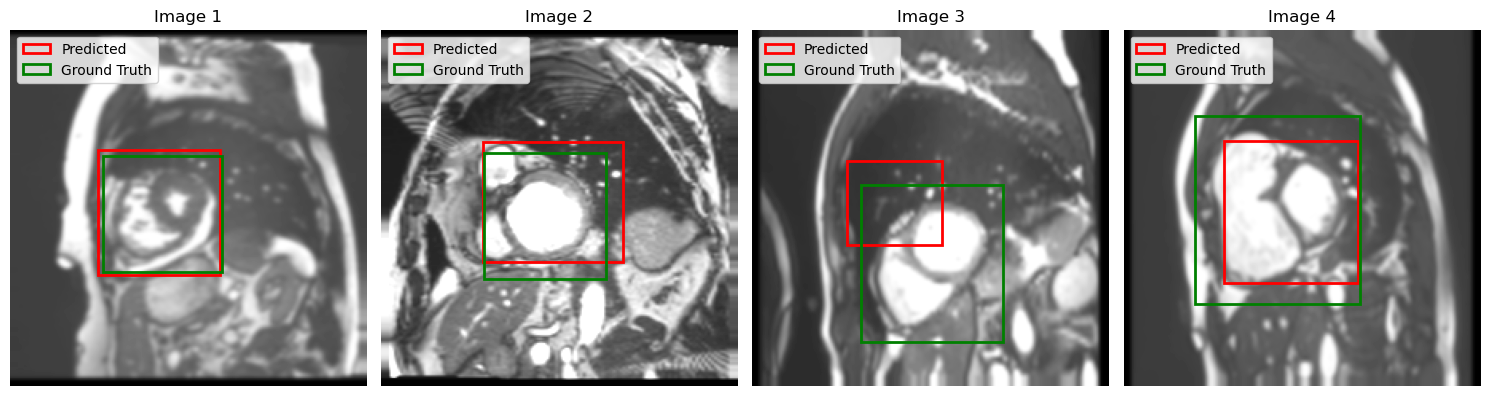

In [14]:
visualize_bounding_boxes(test_dataloader, model, device, num_images=4)

In [ ]:
# torch.cuda.empty_cache()

### Model Evaluation

In [15]:
run_id = "69850586cdab422f90a2580f5c9d0ef5"

with mlflow.start_run(run_id=run_id):
    # Train set
    train_iou = evaluate_iou(dataloader=train_dataloader, model=model, device=device)
    train_mse, train_mae = evaluate_regression_metrics(dataloader=train_dataloader, model=model, device=device)
    print("Train Set:")
    print(f'Train MSE: {train_mse:.4f}\t\t MAE: {train_mae:.4f}\t\t IoU: {train_iou:.4f}')
    mlflow.log_metric("train_mse", round(train_mse.item(), 4))
    mlflow.log_metric("train_mae", round(train_mae.item(), 4))
    mlflow.log_metric("train_iou", round(train_iou.item(), 4))

    # Validation set
    val_iou = evaluate_iou(dataloader=val_dataloader, model=model, device=device)
    val_mse, val_mae = evaluate_regression_metrics(dataloader=val_dataloader, model=model, device=device)
    print("Validation Set:")
    print(f'Validation MSE: {val_mse:.4f}\t\t MAE: {val_mae:.4f}\t\t IoU: {val_iou:.4f}')
    mlflow.log_metric("val_mse", round(val_mse.item(), 4))
    mlflow.log_metric("val_mae", round(val_mae.item(), 4))
    mlflow.log_metric("val_iou", round(val_iou.item(), 4))

    # Test set
    test_iou = evaluate_iou(dataloader=test_dataloader, model=model, device=device)
    test_mse, test_mae = evaluate_regression_metrics(dataloader=test_dataloader, model=model, device=device)
    print("Test Set:")
    print(f'Test MSE: {test_mse:.4f}\t\t MAE: {test_mae:.4f}\t\t IoU: {test_iou:.4f}')
    mlflow.log_metric("test_mse", round(test_mse.item(), 4))
    mlflow.log_metric("test_mae", round(test_mae.item(), 4))
    mlflow.log_metric("test_iou", round(test_iou.item(), 4))

Train Set:
Train MSE: 0.0103		 MAE: 0.1174		 IoU: 0.7288


AttributeError: 'float' object has no attribute 'item'